# `FRBs_GWs_MCMC` test code

In [1]:
import numpy as np
import arviz as az

import corner
import matplotlib.pyplot as plt

import scipy.stats as st
import scipy.constants as const
from scipy.integrate import quad

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
## Defining useful constants (SI)
OMEGA_MATTER = 0.2865
W_LAMBDA = -1
HUBBLE = 69.3
KM_2_MPC = 3.24e-20 
OMEGA_BARYONS = 0.049
f_IGM = 0.83

C_LIGHT = const.c
PI = const.pi
G_NEWTON = const.G
M_PROTON = const.m_p

DM_2_PCCM3 = 3.24e-23  # Multiply with this to get from the SI result to pc/cm^3

SNR_GW = 8
DL_ERROR_PERC = 10
SIGMA_DM = 105

In [3]:
import jax
import jax.numpy as jnp

import numpyro
from numpyro import distributions as dist, infer

numpyro.set_host_device_count(2)

Check [here](https://jax.readthedocs.io/en/latest/_autosummary/jax.scipy.integrate.trapezoid.html#jax.scipy.integrate.trapezoid) to add integration

In [4]:
def Hubble_function(z, H0, Omega_m):
    """
    Hubble function
    """
    return jnp.sqrt(H0**2*(Omega_m*(1+z)**3+(1-Omega_m)))


def rate_function(z):
    rate = (1+2*z)*(z<=1)+3/4*(5-z)*(z>1)*(z<5)
    
    return rate

def D_comoving(z, H0, Omega_m):
    return FlatLambdaCDM(H0, Omega_m).comoving_distance(z).value


###############################################


def dDL_integrand_w(z, Om, w):
    """
    Function of the integrand of the dL formula, 
    eq. (5) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    """
    return 1/jnp.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))


def dDM_integrand_w(z, Om, w):
    """
    Function of the integrand of the DM formula, 
    eq. (12) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    """
    return (1+z)/jnp.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))


def dispersion_measure(z, H0, Om, w=-1):
    """
    Function of the DM formula, 
    eq. (12) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    H0 : Hubble constant [km/s/Mpc]
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    DM : Dispersion measure [pc/cm^3]
    """    

    factor = 3*C_LIGHT*(H0*KM_2_MPC)*OMEGA_BARYONS*f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    # integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    z_grid = jnp.linspace(0.01, z, 1000)
    integrand = dDM_integrand_w(z_grid, Om, w)
    integral = jnp.trapz(integrand.T, z_grid.T)
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

def luminosity_distance(z, H0, Om, w=-1):
    """
    Function of the dL formula, 
    eq. (5) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    H0 : Hubble constant [km/s/Mpc]
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    dL : Luminosity distance [Mpc]
    """      

    factor = (1+z)*(C_LIGHT*1e-3)/H0
    # integral = quad(dDL_integrand_w, 0, z, args=(Om, w))[0]
        
    z_grid = jnp.linspace(0.01, z, 1000)
    integrand = dDL_integrand_w(z_grid, Om, w)
    integral = jnp.trapz(integrand.T, z_grid.T)  
        
    dL = factor*integral
    
    return dL


def dLDM_measure(z, H0, Om, w=-1):
    """
    Function that calculates the dLDM product.
    
    Input
    ----------
    z : redshift
    
    H0 : Hubble constant [km/s/Mpc]
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    dLDM : Luminosity distance x Dispersion Measure [Mpc x pc/cm^3]
    """

    dL = luminosity_distance(z, H0, Om, w)
    DM = dispersion_measure(z, H0, Om, w)
    
    dLDM = dL*DM
    
    return dLDM


def sigma_dL(z, H0, Om, w=-1, method='Wei'):
    """
    Function that calculates the error of dL,
    eq. (10) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    s_dL : distance erro in Mpc
    """      
    
    dL = luminosity_distance(z, H0, Om, w)
    
    if method == 'Wei':
        
        first_term = 2*dL/SNR_GW
        second_term = 0.05*z*dL
        
        s_dL = jnp.sqrt(first_term**2+second_term**2)
        
    elif method == 'constant':
        s_dL = dL/DL_ERROR_PERC
        
    else:
        print("Wrong error method!")
    
    return s_dL


def sigma_dLDM(dL, DM, error_dL):
    """
    Function that calculates the error of dLDM product,
    eq. (14) in [arXiv:1805.12265].
    
    Input
    ----------
    dL : Luminosity distance [Mpc]
    
    DM : Dispersion measure [pc/cm^3]
    
    error_dL : Error in luminosity distance [Mpc]
    
    Output
    ---------
    s_dLDM : Error in the product dLDM [Mpc x pc/cm^3]
    """    
       
    s_dL = error_dL
    s_DM = SIGMA_DM
    
    first_term = (DM*s_dL)**2
    second_term = (dL*s_DM)**2
    
    s_dLDM = jnp.sqrt(first_term+second_term)
    
    return s_dLDM

In [5]:
from numpy.random import default_rng
rng = default_rng(seed=1)

In [6]:
z_range = np.linspace(0.2, 2.0, 500)

z_obs = np.random.choice(z_range, size=50, replace=False)

dL_values_fid = np.zeros_like(z_range)
DM_values_fid = np.zeros_like(z_range)
dLDM_fid = np.zeros_like(z_range)

dL_values_obs = np.zeros_like(z_obs)
DM_values_obs = np.zeros_like(z_obs)
s_dL_obs = np.zeros_like(z_obs)

dLDM_obs = np.zeros_like(z_obs)
s_dLDM_obs = np.zeros_like(z_obs)

# obs values
for idx, z_val in enumerate(z_obs): 
    dL_fid = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_fid = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    
    s_dL_obs[idx] = sigma_dL(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA, method='Wei')
    s_DM_fid = SIGMA_DM
    
    dL_values_obs[idx] = np.random.normal(dL_fid, s_dL_obs[idx])
    DM_values_obs[idx] = np.random.normal(DM_fid, s_DM_fid)
    
    dLDM_obs[idx] = dL_values_obs[idx]*DM_values_obs[idx]
    s_dLDM_obs[idx] = sigma_dLDM(dL_values_obs[idx], DM_values_obs[idx], s_dL_obs[idx])
    
# fid values
for idx, z_val in enumerate(z_range): 
    dL_values_fid[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_values_fid[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)   
    dLDM_fid[idx] = dLDM_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


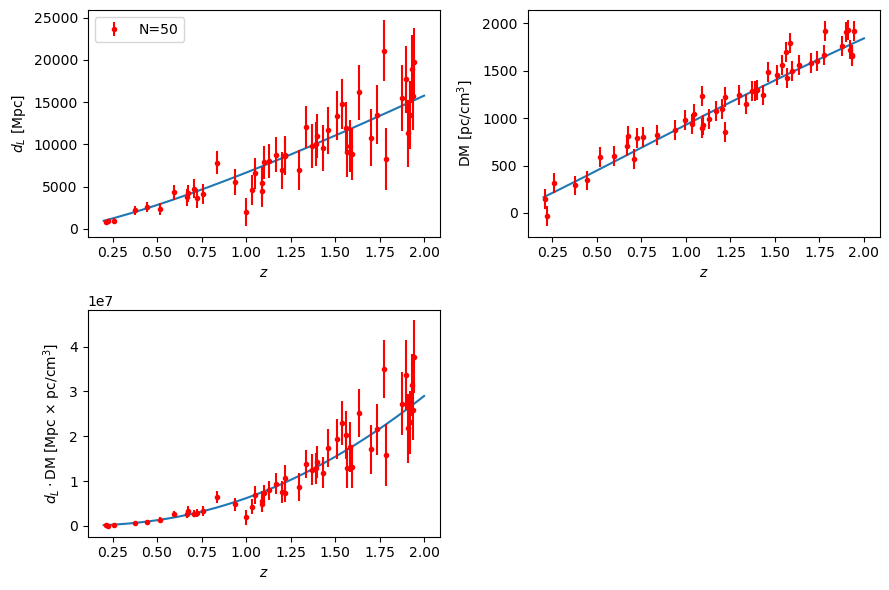

In [7]:
fig = plt.figure(figsize=(9,6))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)

ax1.plot(z_range, dL_values_fid)
ax1.errorbar(z_obs, dL_values_obs, yerr=s_dL_obs, marker='o', ls='', ms=3, c='r', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(z_range, DM_values_fid)
ax2.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

ax3.plot(z_range, dLDM_fid)
ax3.errorbar(z_obs, dLDM_obs, yerr=s_dLDM_obs, marker='o', ls='', ms=3, c='r')
ax3.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [Mpc $\times$ pc/cm$^3$]')
ax3.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

---------------------------------------

In [8]:
def cosmo_model(redshifts, Derr, Dmeasure=None):
    # These are the parameters that we're fitting and we're required to define explicit
    # priors using distributions from the numpyro.distributions module.
    Om = numpyro.sample("Om", dist.Uniform(0, 0.6))
    w = numpyro.sample("w", dist.Uniform(-3, 0))

    with numpyro.plate("data", len(redshifts)):
        Dm = dLDM_measure(redshifts, HUBBLE, Om, w)
        numpyro.sample("y", dist.Normal(Dm, Derr), obs=Dmeasure)

In [9]:
sampler = infer.MCMC(
    infer.NUTS(cosmo_model),
    num_warmup=1000,
    num_samples=6000,
    num_chains=2,
    progress_bar=True,
)
%time sampler.run(jax.random.PRNGKey(0), z_obs, s_dLDM_obs, Dmeasure=dLDM_obs)

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

CPU times: user 4min 57s, sys: 155 ms, total: 4min 57s
Wall time: 2min 39s


In [10]:
inf_data = az.from_numpyro(sampler)
az.summary(inf_data)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Om,0.208,0.121,0.000,0.406,0.003,0.002,2208.0,2144.0,1.0
w,-0.882,0.415,-1.687,-0.428,0.009,0.007,2252.0,2066.0,1.0


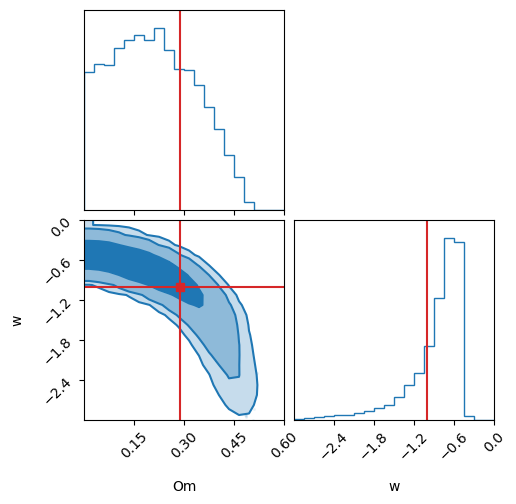

In [11]:
limits = [(0.0, 0.6), (-3.0, 0.0)]
figure = corner.corner(inf_data, truths={"Om": OMEGA_MATTER, "w": W_LAMBDA}, smooth=True, fill_contours=True, color='tab:blue',\
                       truth_color='tab:red', levels=(0.68, 0.95, 0.99), range=limits)